### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [4]:
data = pd.read_csv('data/coupons.csv')

In [5]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [6]:
# Get total rows count
total_count = data.shape[0]
print(f'Total count: {total_count}\n')

# Get a summary of null values count per column
null_counts = data.isnull().sum()
columns_with_nulls = null_counts[null_counts > 0].sort_values(ascending=False)

df_null_columns = columns_with_nulls.to_frame()
df_null_columns.rename(columns={0: 'null counts'}, inplace=True)
df_null_columns['Percentage of Null values (%)'] = (df_null_columns['null counts'] / total_count) * 100
df_null_columns


Total count: 12684



,null counts,Percentage of Null values (%)
car,12576,99.148534
CoffeeHouse,217,1.710817
Restaurant20To50,189,1.490066
CarryAway,151,1.190476
RestaurantLessThan20,130,1.024913
Bar,107,0.843582


3. Decide what to do about your missing data -- drop, replace, other...

In [7]:
# almost 99% of records don't have value in column 'car' (see dataframe in section 2).
# We can ignore this column in our analysis, or treat these as a separate category, i.e. 'Unknown'

df_afterfillna = data.fillna({'car': 'Unknown'})

# Based on https://www.hubresearch.ca/bridging-the-data-gap-how-to-deal-with-missing-data-in-observational-studies/#:~:text=As%20a%20rule%20of%20thumb%2C%20if%20less,be%20deleted%20without%20any%20significant%20ramifications%20(3),
# if less than 5% of the observations are missing, the missing data can simply be deleted without any significant ramification
# Except for column 'car', all other columns have total null values that is around 1% of the total count (see section 2 above).
# So we drop these rows.

df_clean = df_afterfillna.dropna(subset=['CoffeeHouse', 'Restaurant20To50', 'CarryAway', 'RestaurantLessThan20', 'Bar'], how='any')
print(f'total records count after cleaning null values: {df_clean.shape[0]}\n')
print('We will use this dataframe after cleaning, \"df_clean\", for our analysis')


total records count after cleaning null values: 12079

We will use this dataframe after cleaning, "df_clean", for our analysis


4. What proportion of the total observations chose to accept the coupon?



In [8]:
# Count rows where column 'Y' is 1 and divide by the total records then multiply by 100 to get proportion that accept coupon
percentage_yes = (  (df_clean['Y'] == 1).sum() / df_clean.shape[0]  ) * 100
print(f'Percentage of total observations that chose to accept the coupon: {percentage_yes:.2f}%')

Percentage of total observations that chose to accept the coupon: 56.93%


5. Use a bar plot to visualize the `coupon` column.

/tmp/ipykernel_20159/3766914473.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar_graph.set_xticklabels(bar_graph.get_xticklabels(), rotation=45, ha='right')


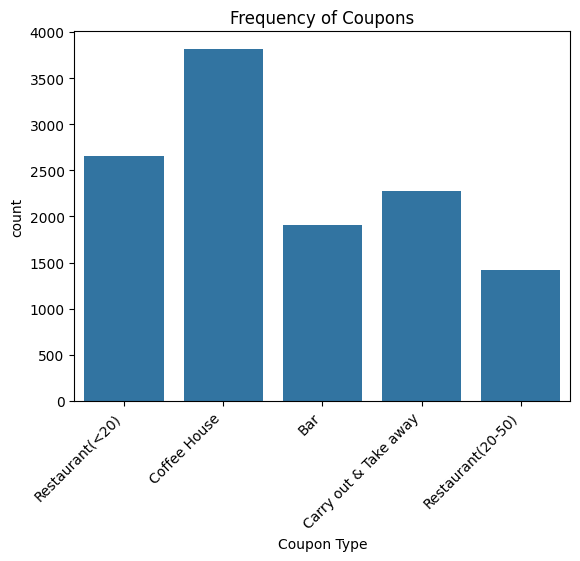

In [9]:
#df_clean['coupon'].value_counts().plot(kind='bar', figsize=(8, 5), color='skyblue')

# Use Seaborn countplot, which is a special kind of bar plot. countplot save 1 extra step of counting the coupons per category:
bar_graph = sns.countplot(x='coupon', data=df_clean)
bar_graph.set_xticklabels(bar_graph.get_xticklabels(), rotation=45, ha='right')
plt.xlabel('Coupon Type')
plt.title('Frequency of Coupons')
plt.savefig('images/coupon_bar_graph.png', bbox_inches='tight')


6. Use a histogram to visualize the temperature column.

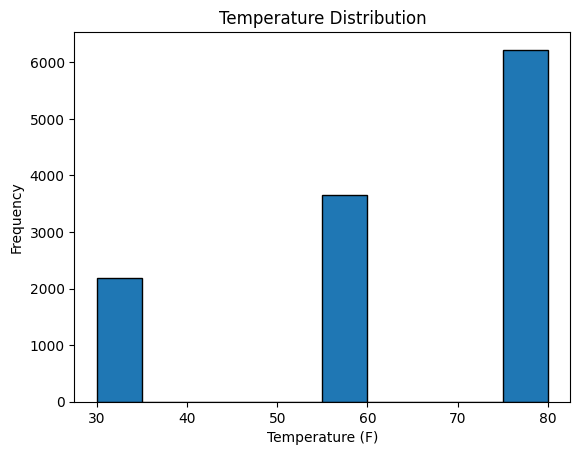

In [10]:
# Plot a histogram of temperature column
df_clean['temperature'].plot(kind='hist', edgecolor='black')
plt.title('Temperature Distribution')
plt.xlabel('Temperature (F)')
plt.ylabel('Frequency')
plt.savefig('images/temperature_histogram.png', bbox_inches='tight')


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [11]:
# only 'bar' coupons
df_bar = df_clean[df_clean['coupon'] == 'Bar']
print(f'Total Bar coupons: {df_bar.shape[0]}')
df_bar_accepted_info = df_bar.groupby('Y')['Y'].value_counts()
print('Bar coupons acceptance summary:\n')
print(df_bar_accepted_info)


Total Bar coupons: 1913
Bar coupons acceptance summary:

Y
0    1125
1     788
Name: count, dtype: int64


2. What proportion of bar coupons were accepted?


In [12]:
total_bar_coupon = df_bar.shape[0]
total_bar_coupon_accepted = (df_bar['Y'] == 1).sum()
print(f'Total bar coupons issued is {total_bar_coupon}. Out of these, {total_bar_coupon_accepted} were accepted')
percentage_bar_coupon_accepted = (  total_bar_coupon_accepted / total_bar_coupon  ) * 100
print(f'Percentage of bar coupons that were accepted: {percentage_bar_coupon_accepted:.2f}%')


Total bar coupons issued is 1913. Out of these, 788 were accepted
Percentage of bar coupons that were accepted: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Bar frequency: ['1~3' '4~8' 'gt8' 'less1' 'never']

Below is the dataframe that shows metric for 2 groups (those that go to bar 3 or fewer times vs More than 3 times)

                   Total_Offered  Accepted  Acceptance Rate (%)
Group                                                          
3 or fewer times            1720       641                37.27
More than 3 times            193       147                76.17




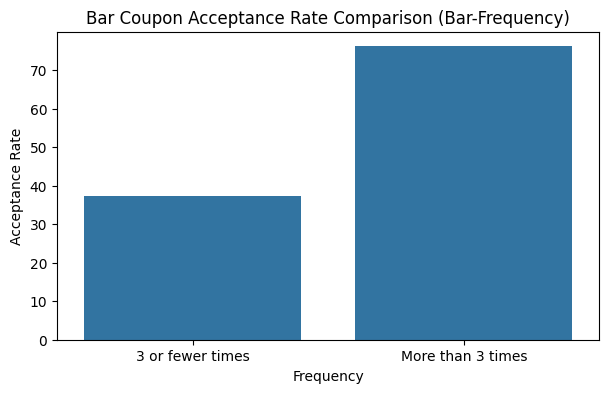


The acceptance rate by those who went to bar more than 3 times is twice
as many as the acceptance rate by those who went to bar 3 times or less


In [37]:
# Find all parameters for 'bar' column
list_temp = df_bar.sort_values('Bar')['Bar'].unique()
print(f'Bar frequency: {list_temp}\n')

# Define the mapping for 2 groups: '3 or fewer times' vs 'More than 3 times'
# Divide the unique parameters from above into these 2 groups
group_map = {
    '1~3'   : '3 or fewer times',
    'less1' : '3 or fewer times',
    'never' : '3 or fewer times',

    '4~8'   : 'More than 3 times',
    'gt8'   : 'More than 3 times'
}

# Apply mapping to create a 'Group' column
df_bar_frequency = df_bar.copy()
df_bar_frequency['Group'] = df_bar_frequency['Bar'].map(group_map)

# Group and calculate metrics
# Using named aggregation to get total coupons offered and sum of Y = 1 simultaneously
df_bar_frequency = df_bar_frequency.groupby('Group').agg(Total_Offered=('Y', 'count'), Accepted=('Y', 'sum'))

# Calculate the ratio
df_bar_frequency['Acceptance Rate (%)'] = round(df_bar_frequency['Accepted'] / df_bar_frequency['Total_Offered'] * 100, 2)

# Display results
print("Below is the dataframe that shows metric for 2 groups (those that go to bar 3 or fewer times vs More than 3 times)\n")
print(df_bar_frequency)
print('\n')

# Graphing logic using Seaborn
plt.figure(figsize=(7, 4))
#bars = plt.bar(df_bar_frequency['Group'], df_bar_frequency['Acceptance Rate (%)'], color=['skyblue', 'lightcoral'])
sns.barplot(y='Acceptance Rate (%)', x = 'Group', data=df_bar_frequency)
plt.ylabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate Comparison (Bar-Frequency)')
plt.xlabel("Frequency")
plt.savefig('images/bar_coupon_based_on_bar_frequency.png', bbox_inches='tight')
plt.show()

print("""\nThe acceptance rate by those who went to bar more than 3 times is twice
as many as the acceptance rate by those who went to bar 3 times or less""")


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Age groups: ['21' '26' '31' '36' '41' '46' '50plus' 'below21']

Below is the dataframe that shows metrics of 2 distinct groups (Frequent Bar-Goers (>25 years old) vs All Others)

                       Total_Offered  Accepted  Acceptance Rate (%)
Group                                                              
>25 yrs old bar-goers            403       278                68.98
all others                      1510       510                33.77



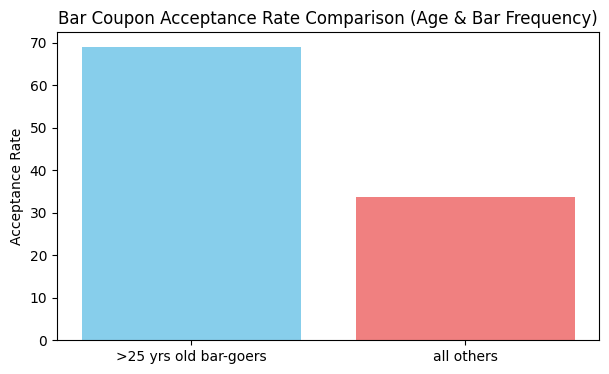

In [25]:
# to find all parameters for 'age' column
list_temp = df_bar.sort_values('age')['age'].unique()
print(f'Age groups: {list_temp}\n')

# Define the group criteria using bar & age parameters from result above
# Group 1: 'bar' in ['1~3', '4~8', 'gt8'] AND 'age' in ['26', '31', '36', '41', '46', '50plus']
df_bar_condition = df_bar['Bar'].isin(['1~3', '4~8', 'gt8'])
df_age_condition = df_bar['age'].isin(['26', '31', '36', '41', '46', '50plus'])

# Create a 'Group' column to define groups
df_bar_and_age = df_bar.copy()
df_bar_and_age['Group'] = np.where(df_bar_condition & df_age_condition, '>25 yrs old bar-goers', 'all others')

# Group by 'Group' and calculate statistics
df_bar_and_age = df_bar_and_age.groupby('Group')['Y'].agg(Total_Offered = 'count', Accepted = 'sum')

# Calculate the ratio
df_bar_and_age['Acceptance Rate (%)'] = round(df_bar_and_age['Accepted'] / df_bar_and_age['Total_Offered'] *100, 2)

print("Below is the dataframe that shows metrics of 2 distinct groups (Frequent Bar-Goers (>25 years old) vs All Others)\n")

print(f'{df_bar_and_age}\n')

# Graphing logic using matplotlib
plt.figure(figsize=(7, 4))
plt.bar(df_bar_and_age.index, df_bar_and_age['Acceptance Rate (%)'], color=['skyblue', 'lightcoral'])
plt.ylabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate Comparison (Age & Bar Frequency)')
plt.savefig('images/bar_coupon_based_on_age_n_bar_frequency.png', bbox_inches='tight')
plt.show()


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Passenger Type: ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']

Below is the dataframe that shows metrics for 2 distinct groups ('Target Group' vs All Others).
Target Group: drivers who go to bars more than once a month and had passengers that were not a kid and 
had occupations other than farming, fishing, or forestry)

              Total_Offered  Accepted  Acceptance Rate (%)
Group                                                     
All Others             1724       653                37.88
Target Group            189       135                71.43




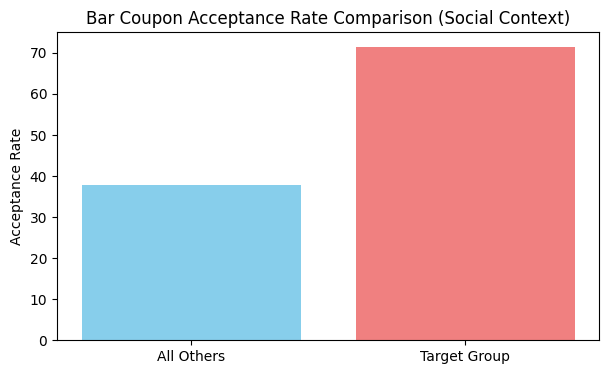

In [36]:
# find all unique parameters for 'passanger' & 'occupation' column
passenger_type = df_bar.sort_values('passanger')['passanger'].unique()
print(f'Passenger Type: {passenger_type}')

# Define the group condition
# Group 1: bar in ['1~3', '4~8', 'gt8'] AND passanger in ['Friend(s)', 'Partner'] AND occupation != 'Farming Fishing & Forestry'
condition = (
              (df_bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &
              (df_bar['passanger'].isin(['Friend(s)', 'Partner'])) &
              (df_bar['occupation'] != 'Farming Fishing & Forestry')
            )

# Create a grouping column
df_bar_occupation_friend = df_bar.copy()
df_bar_occupation_friend['Group'] = np.where(condition, 'Target Group', 'All Others')

# Perform grouping and calculations
df_bar_occupation_friend = df_bar_occupation_friend.groupby('Group').agg(Total_Offered=('Y', 'count'), Accepted=('Y', 'sum'))

# Calculate the acceptance rate, rounded to 2 digits after decimal
df_bar_occupation_friend['Acceptance Rate (%)'] = \
        round(df_bar_occupation_friend['Accepted'] / df_bar_occupation_friend['Total_Offered'] * 100, 2)

# Display
print("""\nBelow is the dataframe that shows metrics for 2 distinct groups ('Target Group' vs All Others).
Target Group: drivers who go to bars more than once a month and had passengers that were not a kid and
had occupations other than farming, fishing, or forestry)\n""")
print(df_bar_occupation_friend)
print('\n')

# Graphing logic
plt.figure(figsize=(7, 4))
plt.bar(df_bar_occupation_friend.index, df_bar_occupation_friend['Acceptance Rate (%)'], color=['skyblue', 'lightcoral'])
plt.ylabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate Comparison (Social Context)')
plt.savefig('images/bar_coupon_based_on_social_context.png', bbox_inches='tight')
plt.show()


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



['1~3' '4~8' 'gt8' 'less1' 'never']


['$100000 or More' '$12500 - $24999' '$25000 - $37499' '$37500 - $49999'
 '$50000 - $62499' '$62500 - $74999' '$75000 - $87499' '$87500 - $99999'
 'Less than $12500']

Below are the dataframe that shows 2 distinct groups ('Drivers with <50K income and go to cheap restaurants vs 
All Others). For each group, shows the total coupons offerred and the total coupons being accepted within the group.
The acceptance rate for each group are also calculated, rounded to 2 digits after decimal

                                Total_Offered  Accepted  Acceptance Rate (%)
Group                                                                       
All others                               1580       636                40.25
Income <50K & Cheap Restaurant            333       152                45.65




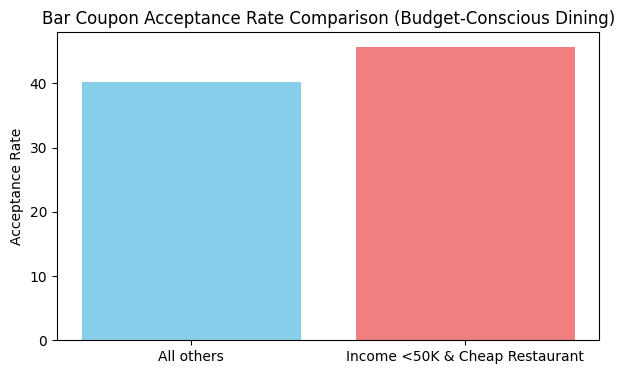

In [28]:
# let's analyze those who go to cheap restaurants more than 4 times a month and income is less than 50K

# find all unique parameters for 'RestaurantLessThan20' & 'income' column
cheap_restaurant_frequency = df_bar.sort_values('RestaurantLessThan20')['RestaurantLessThan20'].unique()
print(cheap_restaurant_frequency)
income_range = df_bar.sort_values('income')['income'].unique()
print('\n')
print(income_range)

# Define the conditions for the first group
group_1_restaurants = ['4~8', 'gt8']
group_1_incomes = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

# Create condition for Group 1 membership
is_group_1 = (
                df_bar['RestaurantLessThan20'].isin(group_1_restaurants) &
                df_bar['income'].isin(group_1_incomes)
              )

# Assign groups
# If the condition is true, label it 'Income <50K & Cheap Restaurant', otherwise 'All others'
df_low_income_eat_cheap = df_bar.copy()
df_low_income_eat_cheap['Group'] = np.where(is_group_1, 'Income <50K & Cheap Restaurant', 'All others')

# Perform the aggregation
# Group by the newly created 'Group' column
df_low_income_eat_cheap = df_low_income_eat_cheap.groupby('Group').agg(Total_Offered=('Y', 'size'), Accepted=('Y', 'sum'))

# Calculate the acceptance rate
df_low_income_eat_cheap['Acceptance Rate (%)'] = \
          round(df_low_income_eat_cheap['Accepted'] / df_low_income_eat_cheap['Total_Offered'] * 100, 2)

# Display
print("""\nBelow are the dataframe that shows 2 distinct groups ('Drivers with <50K income and go to cheap restaurants vs
All Others). For each group, shows the total coupons offerred and the total coupons being accepted within the group.
The acceptance rate for each group are also calculated, rounded to 2 digits after decimal\n""")
print(df_low_income_eat_cheap)
print('\n')

# Graphing logic
plt.figure(figsize=(7, 4))
plt.bar(df_low_income_eat_cheap.index, df_low_income_eat_cheap['Acceptance Rate (%)'], color=['skyblue', 'lightcoral'])
plt.ylabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate Comparison (Budget-Conscious Dining)')
plt.savefig('images/bar_coupon_based_on_budget_conscious_dining.png', bbox_inches='tight')
plt.show()


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [17]:
print("""Based on the data provided, the analysis of bar coupon acceptance behavior reveals several key trends:

Overall Acceptance: Bar coupons have a moderate overall acceptance rate of 41.19% (788 accepted out of 1913 issued).

High-Frequency Bar Goers: Drivers who visit bars more than 3 times a month have a significantly higher acceptance rate of 76.17%, compared to only 37.27% for those who visit less frequently.

Age and Demographic Factors: Drivers over the age of 25 who visit a bar at least once a month accept coupons at a higher rate of 68.98%, compared to 33.77% for all other demographics.

Social/Urban Context: Drivers who go to bars more than once a month, are not accompanied by kids, and do not work in farming, fishing, or forestry industries (likely urban/social passengers) show a high acceptance rate of 71.43%.

Economic & Lifestyle Factors: Drivers earning less than $50K annually who frequent cheap restaurants (less than $20) more than 4 times a month have a higher acceptance rate of 45.65%, compared to 40.25% for the rest of the group.

Key Takeaway for Coupon Providers:
The data suggests that the best target audience for bar coupons are individuals who already frequent bars and social spots regularly, particularly those over 25 and in non-agricultural occupations.""")

Based on the data provided, the analysis of bar coupon acceptance behavior reveals several key trends:

Overall Acceptance: Bar coupons have a moderate overall acceptance rate of 41.19% (788 accepted out of 1913 issued).

High-Frequency Bar Goers: Drivers who visit bars more than 3 times a month have a significantly higher acceptance rate of 76.17%, compared to only 37.27% for those who visit less frequently.

Age and Demographic Factors: Drivers over the age of 25 who visit a bar at least once a month accept coupons at a higher rate of 68.98%, compared to 33.77% for all other demographics.

Social/Urban Context: Drivers who go to bars more than once a month, are not accompanied by kids, and do not work in farming, fishing, or forestry industries (likely urban/social passengers) show a high acceptance rate of 71.43%.

Economic & Lifestyle Factors: Drivers earning less than $50K annually who frequent cheap restaurants (less than $20) more than 4 times a month have a higher acceptance ra

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [18]:
df_coupon = df_clean.groupby('coupon')['coupon'].value_counts()
df_coupon


,count
coupon,
Bar,1913
Carry out & Take away,2280
Coffee House,3816
Restaurant(20-50),1417
Restaurant(<20),2653


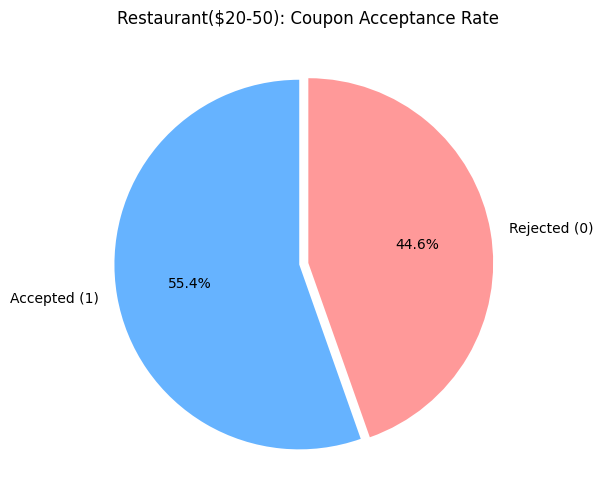

In [31]:
# 'Restaurant(20-50)' coupons are offered 1417 times among drivers (see above).
# Let's find the acceptance ratio for 'Restaurant(20-50)' coupons

# Filter data for 'Restaurant(20-50)'
df_carryout = df_clean[df_clean['coupon'] == 'Restaurant(20-50)']

#Count Y=1 vs Y=0 for this subset
# value_counts() counts occurrences of 1s and 0s
y_counts = df_carryout['Y'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
y_counts.plot.pie(
                  autopct='%1.1f%%',
                  labels=['Accepted (1)', 'Rejected (0)'],
                  startangle=90,
                  colors=['#66b3ff', '#ff9999'],
                  explode=(0.05, 0) # Explode the first slice
                  )

plt.title('Restaurant($20-50): Coupon Acceptance Rate')
plt.ylabel('') # Remove the 'Y' ylabel
plt.savefig('images/midrange_restaurant_coupon.png', bbox_inches='tight')
plt.show()


                   Total_Count  Accepted  Acceptance_Rate
maritalStatus                                            
Single                     551       261            47.37
Unmarried partner          212       100            47.17
Married partner            578       246            42.56
Divorced                    62        22            35.48
Widowed                     14         3            21.43




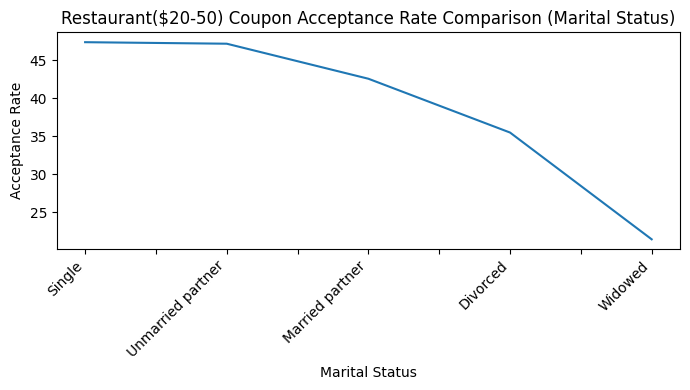

In [33]:
# Let's find out the rate of acceptance among different groups of marrital status
df_carryout = df_clean[df_clean['coupon'] == 'Restaurant(20-50)']
df_marritalStatus = \
      df_carryout.groupby('maritalStatus').agg(
                                                Total_Count = ('Y', 'count'),  # Count total rows in each group
                                                Accepted = ('Y', lambda x: (x == 1).sum()),
                                                Acceptance_Rate = ('Y', lambda x: round((x == 1).sum() / x.count() * 100, 2))
                                              ).sort_values('Acceptance_Rate', ascending=False)
print(df_marritalStatus)
print('\n')

plt.figure(figsize=(7, 4))
df_marritalStatus['Acceptance_Rate'].plot(kind='line')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate')
plt.title('Restaurant($20-50) Coupon Acceptance Rate Comparison (Marital Status)')

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.savefig('images/midrange_restaurant_coupon_based_on_marital_status.png', bbox_inches='tight')
plt.show()


                 Total_Count  Accepted  Acceptance_Rate
destination                                            
Home                      37        15            40.54
No Urgent Place           16         5            31.25
Work                      23         5            21.74




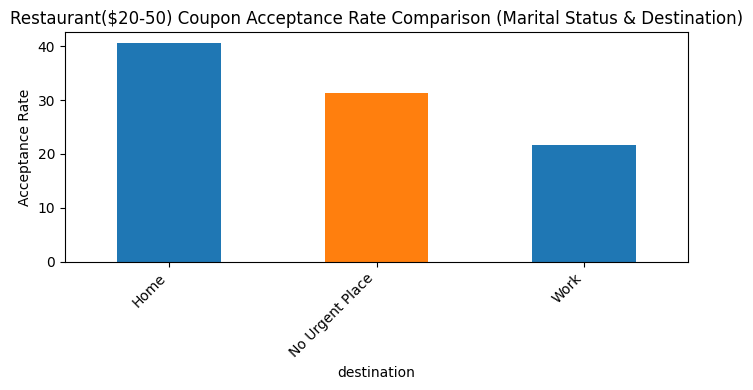

In [34]:
# Looks like divorced and widowed drivers accept the least number of Restaurant(20-50) coupons
# Let's find out the rate of acceptance among divorced & widowed drivers and where are they heading
df_lonely = df_carryout.loc[df_carryout['maritalStatus'].isin(['Divorced', 'Widowed'])]
df_lonely
df_lonely = \
      df_lonely.groupby('destination').agg(
                                            Total_Count = ('Y', 'count'),  # Count total rows in each group
                                            Accepted = ('Y', lambda x: (x == 1).sum()),
                                            Acceptance_Rate = ('Y', lambda x: round((x == 1).sum() / x.count() * 100, 2))
                                          )
print(df_lonely)
print('\n')

plt.figure(figsize=(7, 4))
df_lonely['Acceptance_Rate'].plot(kind='bar', color=['tab:blue', 'tab:orange'])
plt.ylabel('Acceptance Rate')
plt.title('Restaurant($20-50) Coupon Acceptance Rate Comparison (Marital Status & Destination)')

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.savefig('images/midrange_restaurant_coupon_based_on_non_married_n_destination.png', bbox_inches='tight')
plt.show()


                  Total_Count  Accepted  Acceptance_Rate
income                                                  
$25000 - $37499             7         6            85.71
$37500 - $49999             6         3            50.00
Less than $12500            5         2            40.00
$12500 - $24999            17         4            23.53
$50000 - $62499             1         0             0.00
$62500 - $74999             1         0             0.00




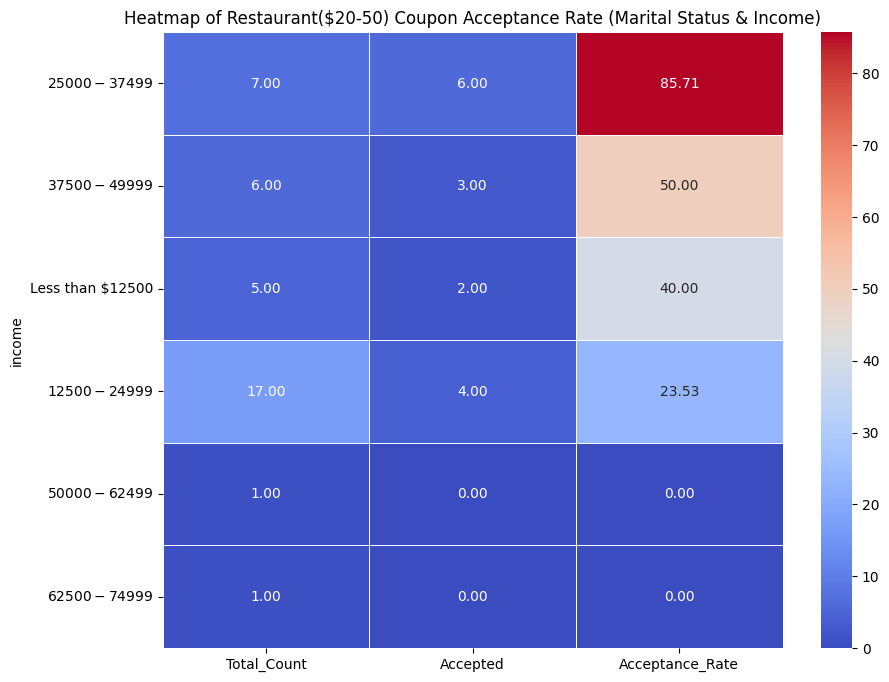

In [35]:
# Seem like widowed and divorced driver going home tend to accept more.
# Let see if the income affect the acceptance rate of this group
df_lonely = df_carryout[df_carryout['maritalStatus'].isin(['Divorced', 'Widowed']) & (df_carryout['destination'] == 'Home')]
df_lonely
df_lonely_income = \
      df_lonely.groupby('income').agg(
                                        Total_Count = ('Y', 'count'),  # Count total rows in each group
                                        Accepted = ('Y', lambda x: (x == 1).sum()),
                                        Acceptance_Rate = ('Y', lambda x: round((x == 1).sum() / x.count() * 100, 2))
                                      ).sort_values('Acceptance_Rate', ascending=False)
print(df_lonely_income)
print('\n')

# Create the heatmap
plt.figure(figsize=(10, 8)) # Optional: Adjust figure size
sns.heatmap(df_lonely_income, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Heatmap of Restaurant($20-50) Coupon Acceptance Rate (Marital Status & Income)")
plt.savefig('images/midrange_restaurant_coupon_based_on_non_married_n_income.png', bbox_inches='tight')
plt.show()
